In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:

df = pd.read_csv('../data/Kenya.csv')
df['Country'] = 'Kenya'

In [4]:
df = df.replace(-999, np.nan)

In [5]:

df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [6]:
print(f"Duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()

Duplicate rows: 0


In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Year,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,2020.131451,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,2015.000000,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,2017.000000,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,2020.000000,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,2023.000000,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,2026.000000,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.248907,3.477046


In [8]:
missing_pct = df.isna().sum() / len(df) * 100
print(missing_pct[missing_pct > 0])   

Series([], dtype: float64)


In [9]:
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
outlier_counts = {}
for col in cols:
    z = np.abs(stats.zscore(df[col].dropna()))
    outliers = np.sum(z > 3)
    outlier_counts[col] = outliers
    print(f"{col}: {outliers} outliers")

for col in cols:
    mean = df[col].mean()
    std = df[col].std()
    df[col] = df[col].clip(mean - 3*std, mean + 3*std)

T2M: 8 outliers
T2M_MAX: 3 outliers
T2M_MIN: 9 outliers
PRECTOTCORR: 92 outliers
RH2M: 6 outliers
WS2M: 0 outliers
WS2M_MAX: 6 outliers


In [12]:

df[cols] = df[cols].ffill()

df = df.dropna(thresh=int(0.7 * len(df.columns)))
print(f"Final shape: {df.shape}")

Final shape: (4108, 16)


In [15]:
df.to_csv('../data/kenya_clean.csv', index=False)
print("Saved cleaned data to ../data/kenya_clean.csv")

Saved cleaned data to ../data/kenya_clean.csv


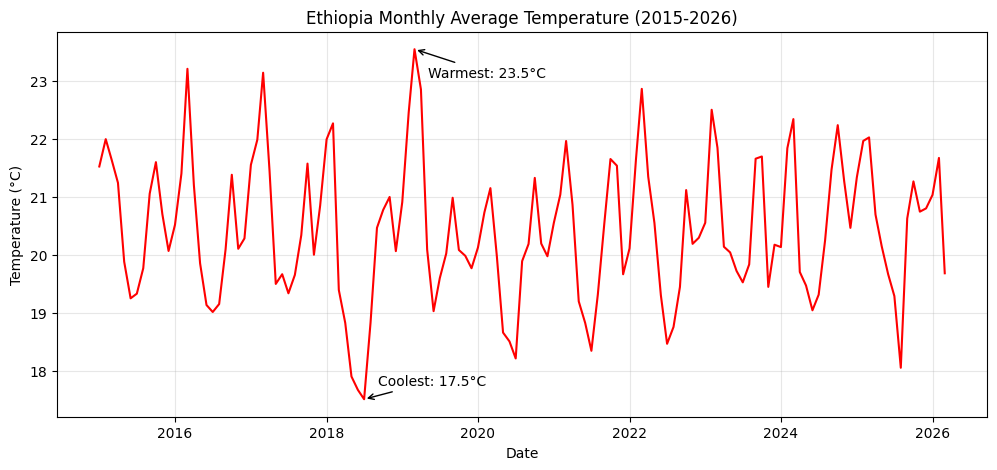

In [16]:
monthly_temp = df.groupby(['Year', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp['Year'].astype(str) + '-' + monthly_temp['Month'].astype(str))

plt.figure(figsize=(12,5))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], linewidth=1.5, color='red')

max_row = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
min_row = monthly_temp.loc[monthly_temp['T2M'].idxmin()]
plt.annotate(f"Warmest: {max_row['T2M']:.1f}°C", xy=(max_row['Date'], max_row['T2M']),
             xytext=(10, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.annotate(f"Coolest: {min_row['T2M']:.1f}°C", xy=(min_row['Date'], min_row['T2M']),
             xytext=(10, 10), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.title('Ethiopia Monthly Average Temperature (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(alpha=0.3)
plt.show()

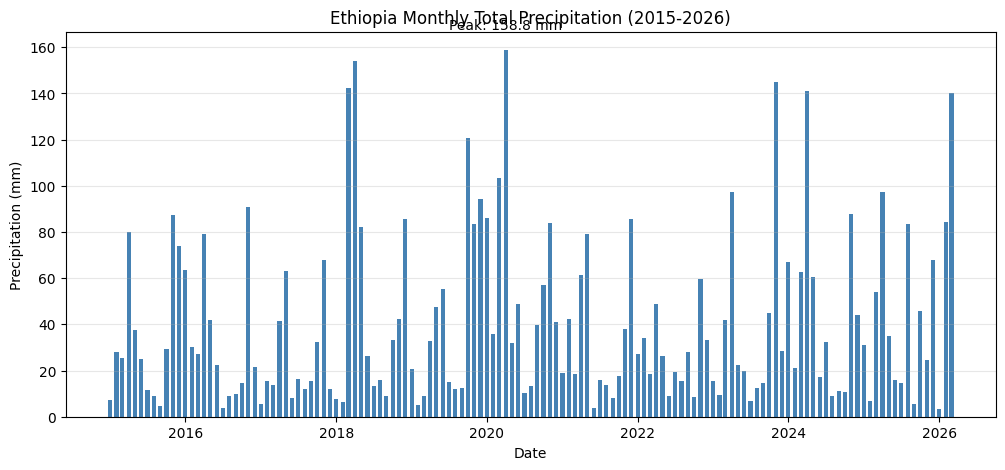

In [17]:
monthly_precip = df.groupby(['Year', 'Month'])['PRECTOTCORR'].sum().reset_index()
monthly_precip['Date'] = pd.to_datetime(monthly_precip['Year'].astype(str) + '-' + monthly_precip['Month'].astype(str))

plt.figure(figsize=(12,5))
plt.bar(monthly_precip['Date'], monthly_precip['PRECTOTCORR'], width=20, color='steelblue')
peak = monthly_precip.loc[monthly_precip['PRECTOTCORR'].idxmax()]
plt.annotate(f"Peak: {peak['PRECTOTCORR']:.1f} mm", xy=(peak['Date'], peak['PRECTOTCORR']),
             xytext=(0, 15), textcoords='offset points', ha='center')
plt.title('Ethiopia Monthly Total Precipitation (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.grid(alpha=0.3, axis='y')
plt.show()

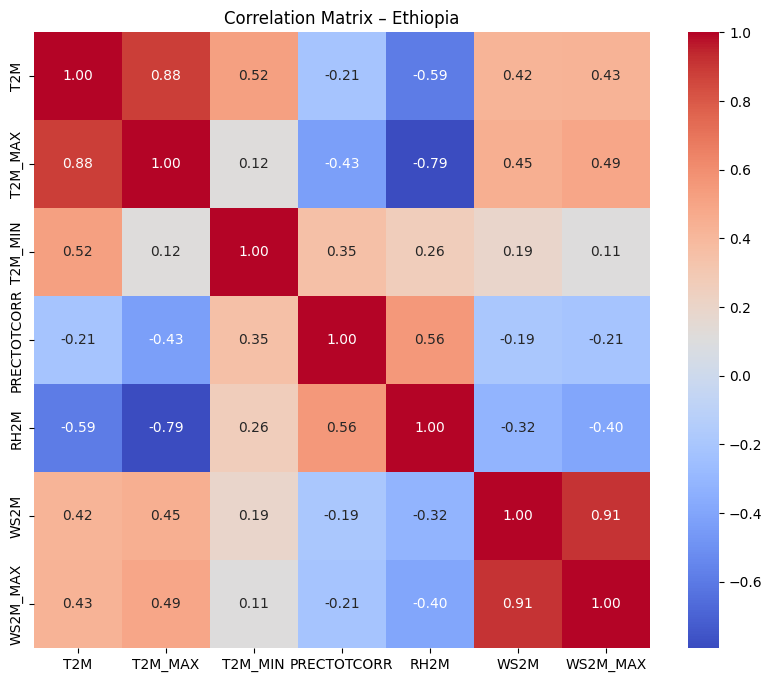

In [18]:
plt.figure(figsize=(10,8))
corr = df[cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix – Ethiopia')
plt.show()

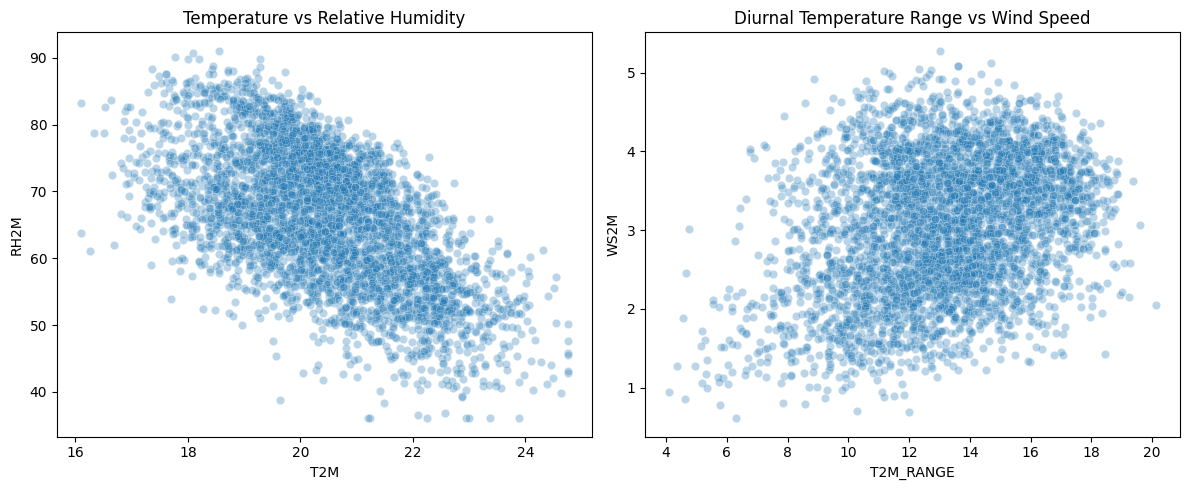

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=axes[0])
axes[0].set_title('Temperature vs Relative Humidity')
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=axes[1])
axes[1].set_title('Diurnal Temperature Range vs Wind Speed')
plt.tight_layout()
plt.show()

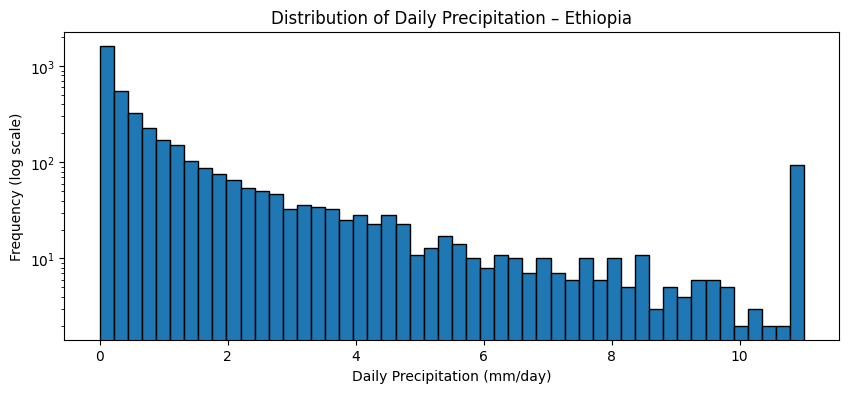

In [20]:
plt.figure(figsize=(10,4))
plt.hist(df['PRECTOTCORR'], bins=50, edgecolor='black')
plt.yscale('log')
plt.xlabel('Daily Precipitation (mm/day)')
plt.ylabel('Frequency (log scale)')
plt.title('Distribution of Daily Precipitation – Ethiopia')
plt.show()

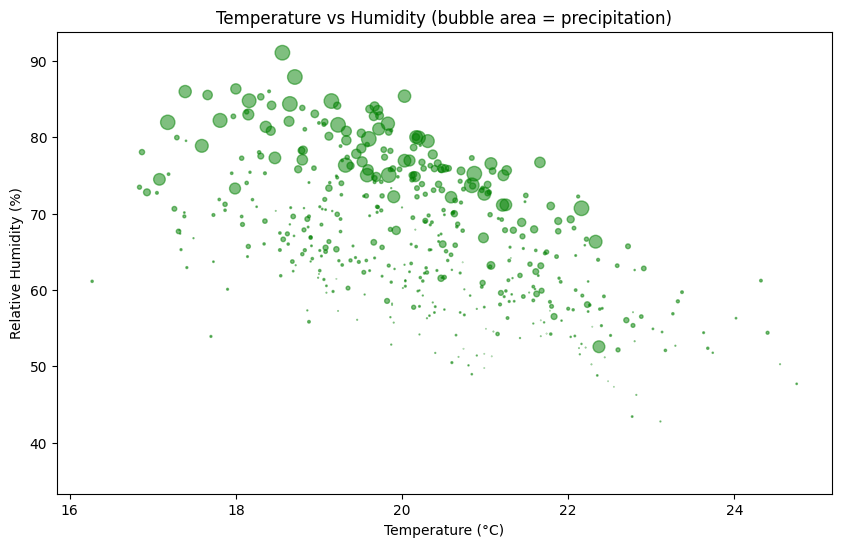

In [21]:
sample = df.sample(min(500, len(df)))  # avoid overcrowding
plt.figure(figsize=(10,6))
plt.scatter(sample['T2M'], sample['RH2M'], s=sample['PRECTOTCORR']*10, alpha=0.5, c='green')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Temperature vs Humidity (bubble area = precipitation)')
plt.show()